In [1]:
import numpy as np

In [2]:
theta_fid1 = {
    'ALPHA_STAR': 0.5,
    'F_STAR10':  -1.3,
    'F_ESC10':   -1.0,
    'ALPHA_ESC': -0.5,
    'M_TURN':     8.7,   
    't_STAR':     0.5,
}

theta_fid2 = {
    'ALPHA_STAR':  0.8,
    'F_STAR10':   -0.8,   # high star formation efficiency
    'F_ESC10':    -0.7,   # high escape fraction
    'ALPHA_ESC':  -0.3,
    'M_TURN':      8.0,   # low turnover — many small halos active
    't_STAR':      0.3,   # fast star formation
}

theta_obs = np.array(list(theta_fid2.values()), dtype=np.float32)

In [3]:
theta_obs
from emulator.scale_theta import scale_thetas
theta_obs = scale_thetas(theta_obs)

In [4]:
from emulator.mdn_model.model_mdn import Emulator21cm,run_inference
CHECKPOINT_DEFAULT = "emulator/mdn_model/checkpoints/emulator.pt"

import torch

In [5]:
def load_emulator():
    model = Emulator21cm(n_params=6, n_redshifts=3)
    model.load_state_dict(torch.load(CHECKPOINT_DEFAULT, map_location="cpu"))
    return model
model   = load_emulator()
checkpoint_dir = "emulator/mdn_model/checkpoints"
scalers = np.load(f"{checkpoint_dir}/scalers.npz")

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import glob
import os

# ----------------------------------
# Load all realizations
# ----------------------------------

files = sorted(glob.glob("gaussian_test1/point_*/ps2d.npy"))

all_ps=[]

for f in files:
    all_ps.append(np.load(f))

all_ps=np.array(all_ps)
#all_ps = np.log(all_ps + 1e-12)  # Avoid log(0)

# shape (Nsims,3,10,10)

print(all_ps.shape)

(1000, 3, 10, 10)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import glob
import os

# ----------------------------------
# Load all realizations
# ----------------------------------

files = sorted(glob.glob("gaussian_test2/point_*/ps2d.npy"))

all_ps2=[]

for f in files:
    all_ps2.append(np.load(f))

all_ps2=np.array(all_ps2)
#all_ps = np.log(all_ps + 1e-12)  # Avoid log(0)

# shape (Nsims,3,10,10)

print(all_ps2.shape)

(1001, 3, 10, 10)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import glob
import os

# ----------------------------------
# Load all realizations
# ----------------------------------

files = sorted(glob.glob("gaussian_test3/point_*/ps2d.npy"))

all_ps3=[]

for f in files:
    all_ps3.append(np.load(f))

all_ps3=np.array(all_ps3)
#all_ps = np.log(all_ps + 1e-12)  # Avoid log(0)

# shape (Nsims,3,10,10)

print(all_ps3.shape)

(1000, 3, 10, 10)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import glob
import os

# ----------------------------------
# Load all realizations
# ----------------------------------

files = sorted(glob.glob("gaussian_test4/point_*/ps2d.npy"))

all_ps4=[]

for f in files:
    all_ps4.append(np.load(f))

all_ps4=np.array(all_ps4)
#all_ps = np.log(all_ps + 1e-12)  # Avoid log(0)

# shape (Nsims,3,10,10)

print(all_ps4.shape)

(1000, 3, 10, 10)


In [10]:
sigma_use = np.concatenate([
            np.loadtxt(f).flatten()
            for f in sorted(glob.glob("PS1_PS2_Data/err_Pk_PS2_*.txt"))])

sigma_use = sigma_use.reshape(3,10,10)

In [11]:
results   = run_inference(model, theta_obs)
ps2d_pi   = results["ps2d_pi"].numpy()    # (1, Z, K, H, W)
ps2d_mu   = results["ps2d_mu"].numpy()    # (1, Z, K, H, W)  — log10 space
ps2d_std  = results["ps2d_std"].numpy()   # (1, Z, K, H, W)  — log10 space
ps2d_mean = results["ps2d_mean"].numpy()  # (1, Z, H, W)     — mixture mean
xhi_mu = results["xhi_mu"].numpy()

In [12]:
xhi_mu

array([[0.9762003, 0.997724 , 0.9998235]], dtype=float32)

/tmp/ipykernel_1372565/872118553.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(fontsize=6, loc="upper right")


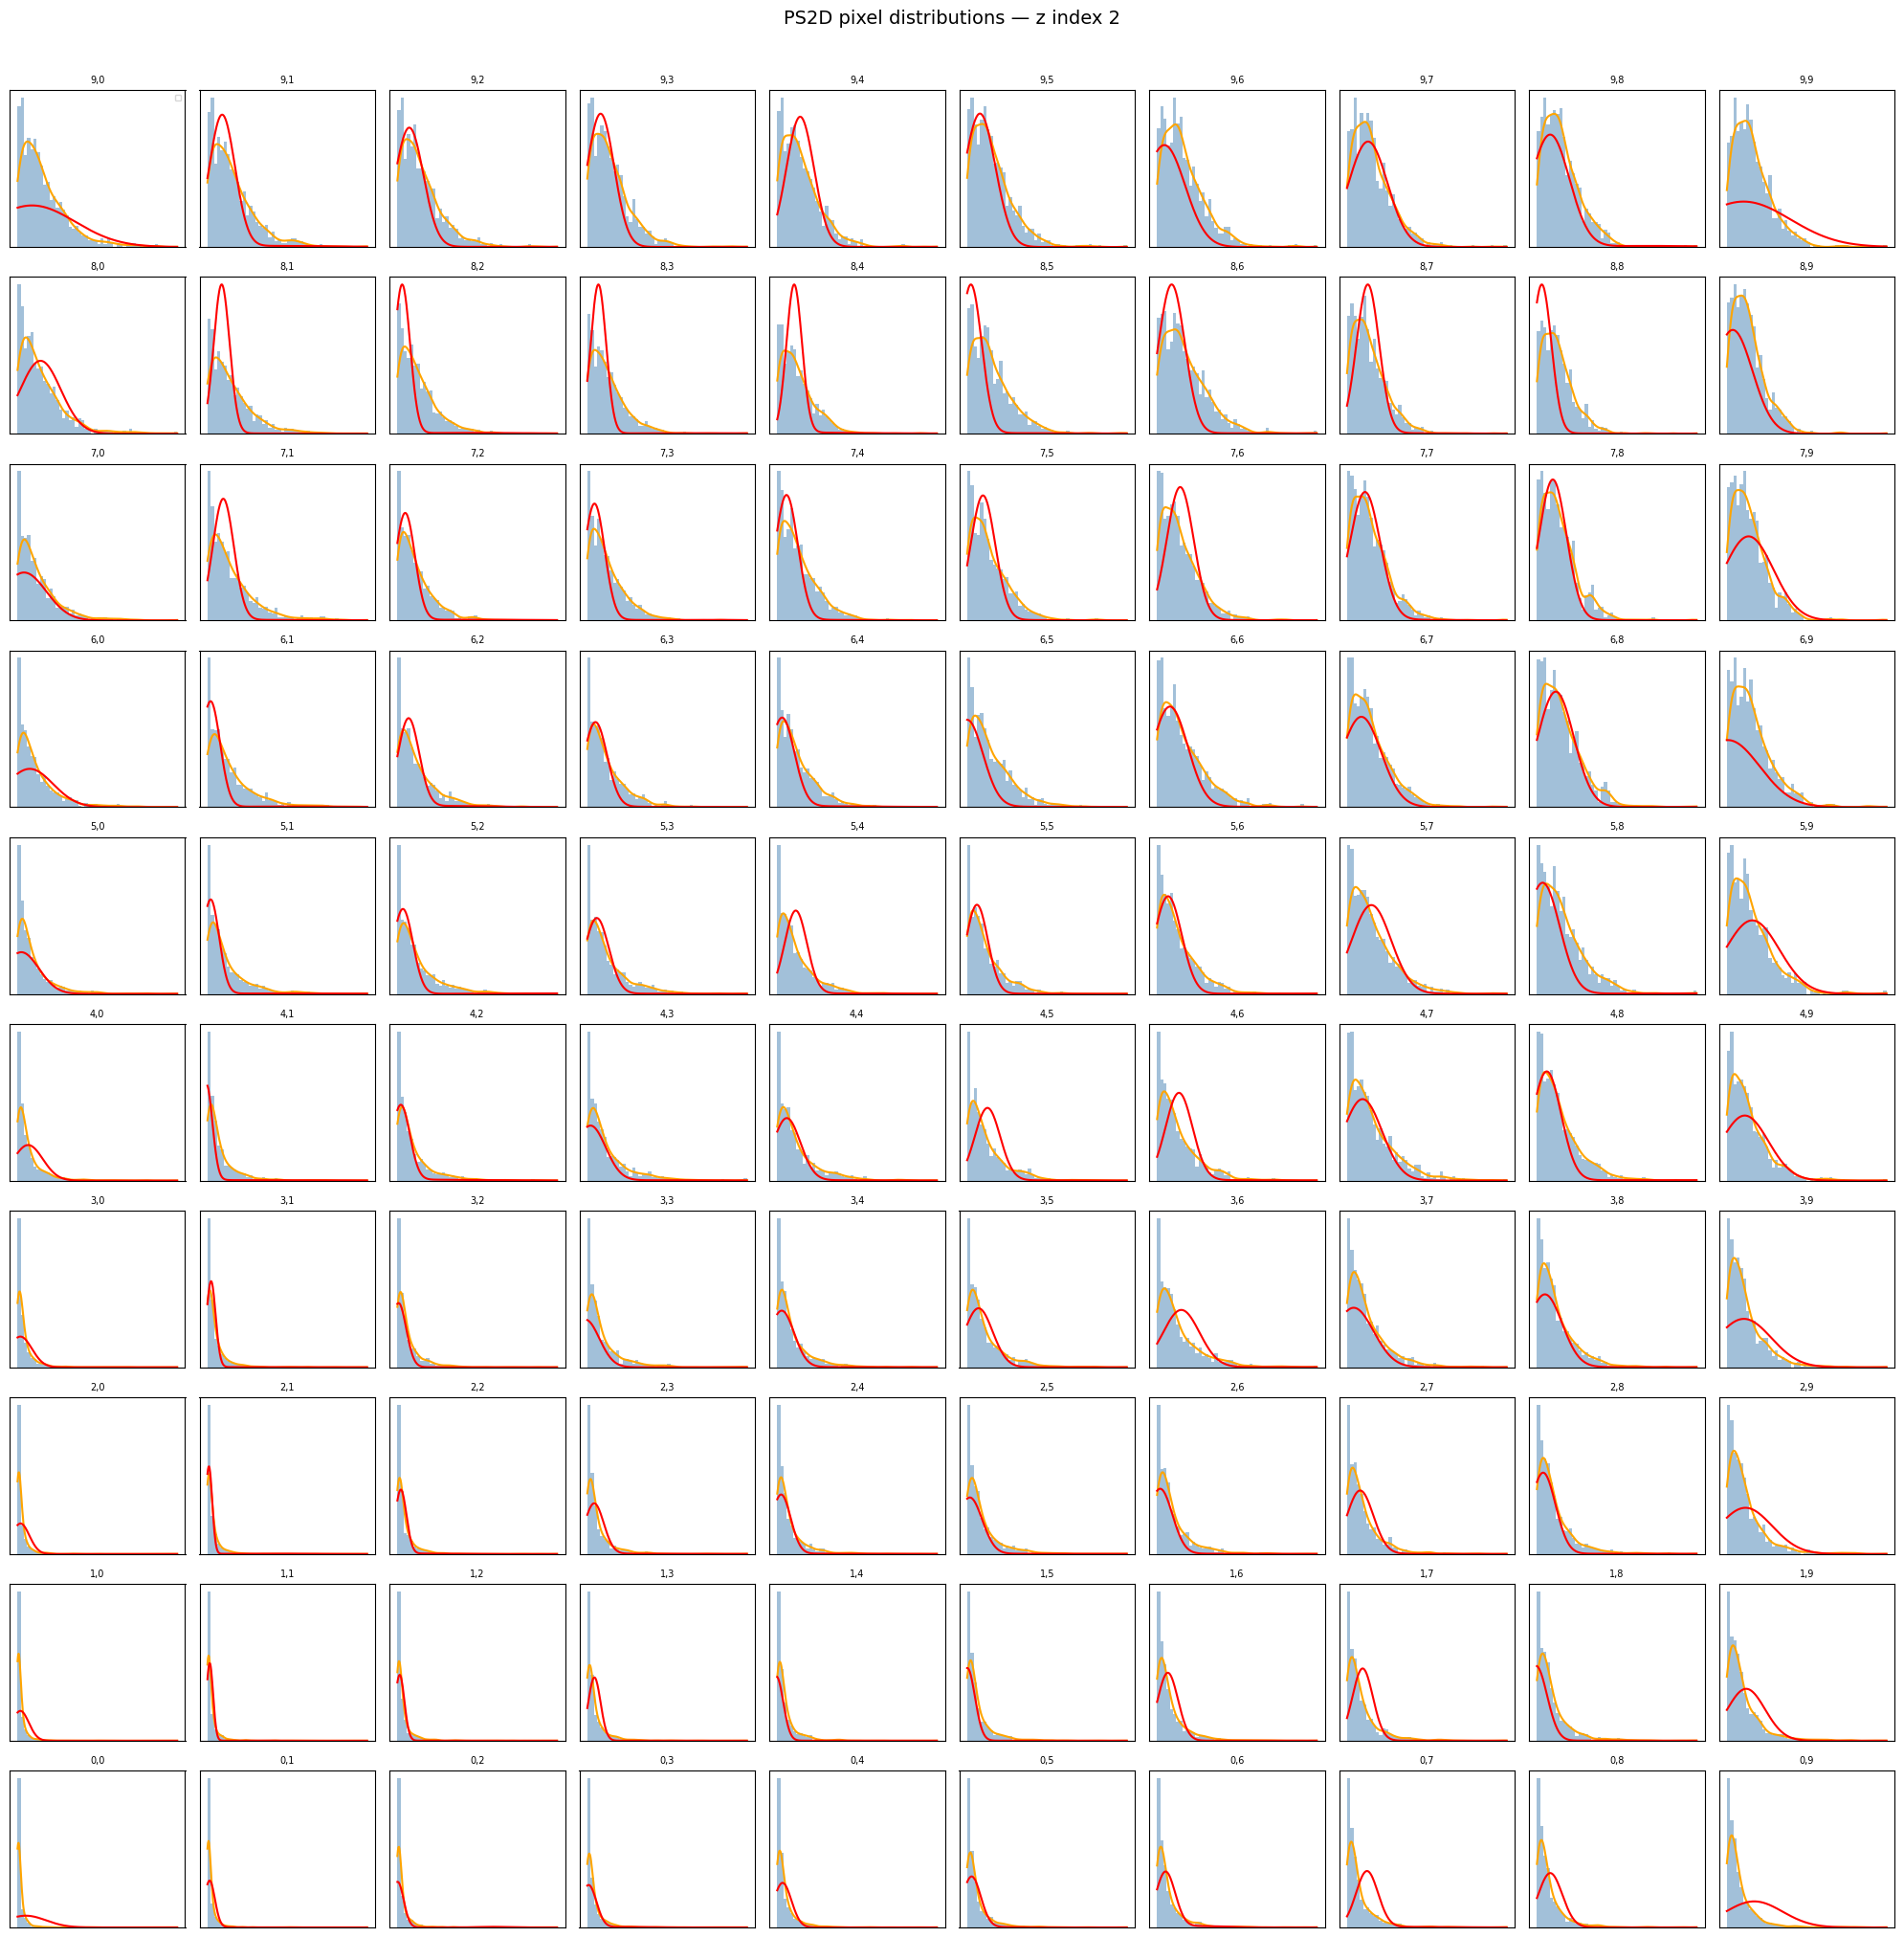

In [13]:
from scipy.stats import gaussian_kde

z_idx = 2
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
for i in range(10):
    for j in range(10):
        ax = axes[9-i, j]

        x  = all_ps2[:, z_idx, i, j]
        xx = np.linspace(x.min(), x.max(), 300)

        ax.hist(x, bins=50, density=True, alpha=0.5, color="steelblue")
        ax.plot(xx, gaussian_kde(x)(xx), color="orange", linewidth=1.5)

        # MDN mixture PDF — directly in linear space
        mixture_pdf = np.zeros_like(xx)
        for k in range(ps2d_pi.shape[2]):
            pi_k  = ps2d_pi [0, z_idx, k, i, j]
            mu_k  = ps2d_mu [0, z_idx, k, i, j]
            sig_k = ps2d_std[0, z_idx, k, i, j]
            mixture_pdf += pi_k * norm.pdf(xx, mu_k, sig_k)

        ax.plot(xx, mixture_pdf, color="red", linewidth=1.5)
        #ax.axvline(ps2d_mean[0, z_idx, i, j], color="red",  linestyle="--", linewidth=1.2)
        #ax.axvline(x.mean(),                  color="blue", linestyle="-",  linewidth=1.2)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{i},{j}", fontsize=7)

axes[0, 0].legend(fontsize=6, loc="upper right")
plt.suptitle(f"PS2D pixel distributions — z index {z_idx}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

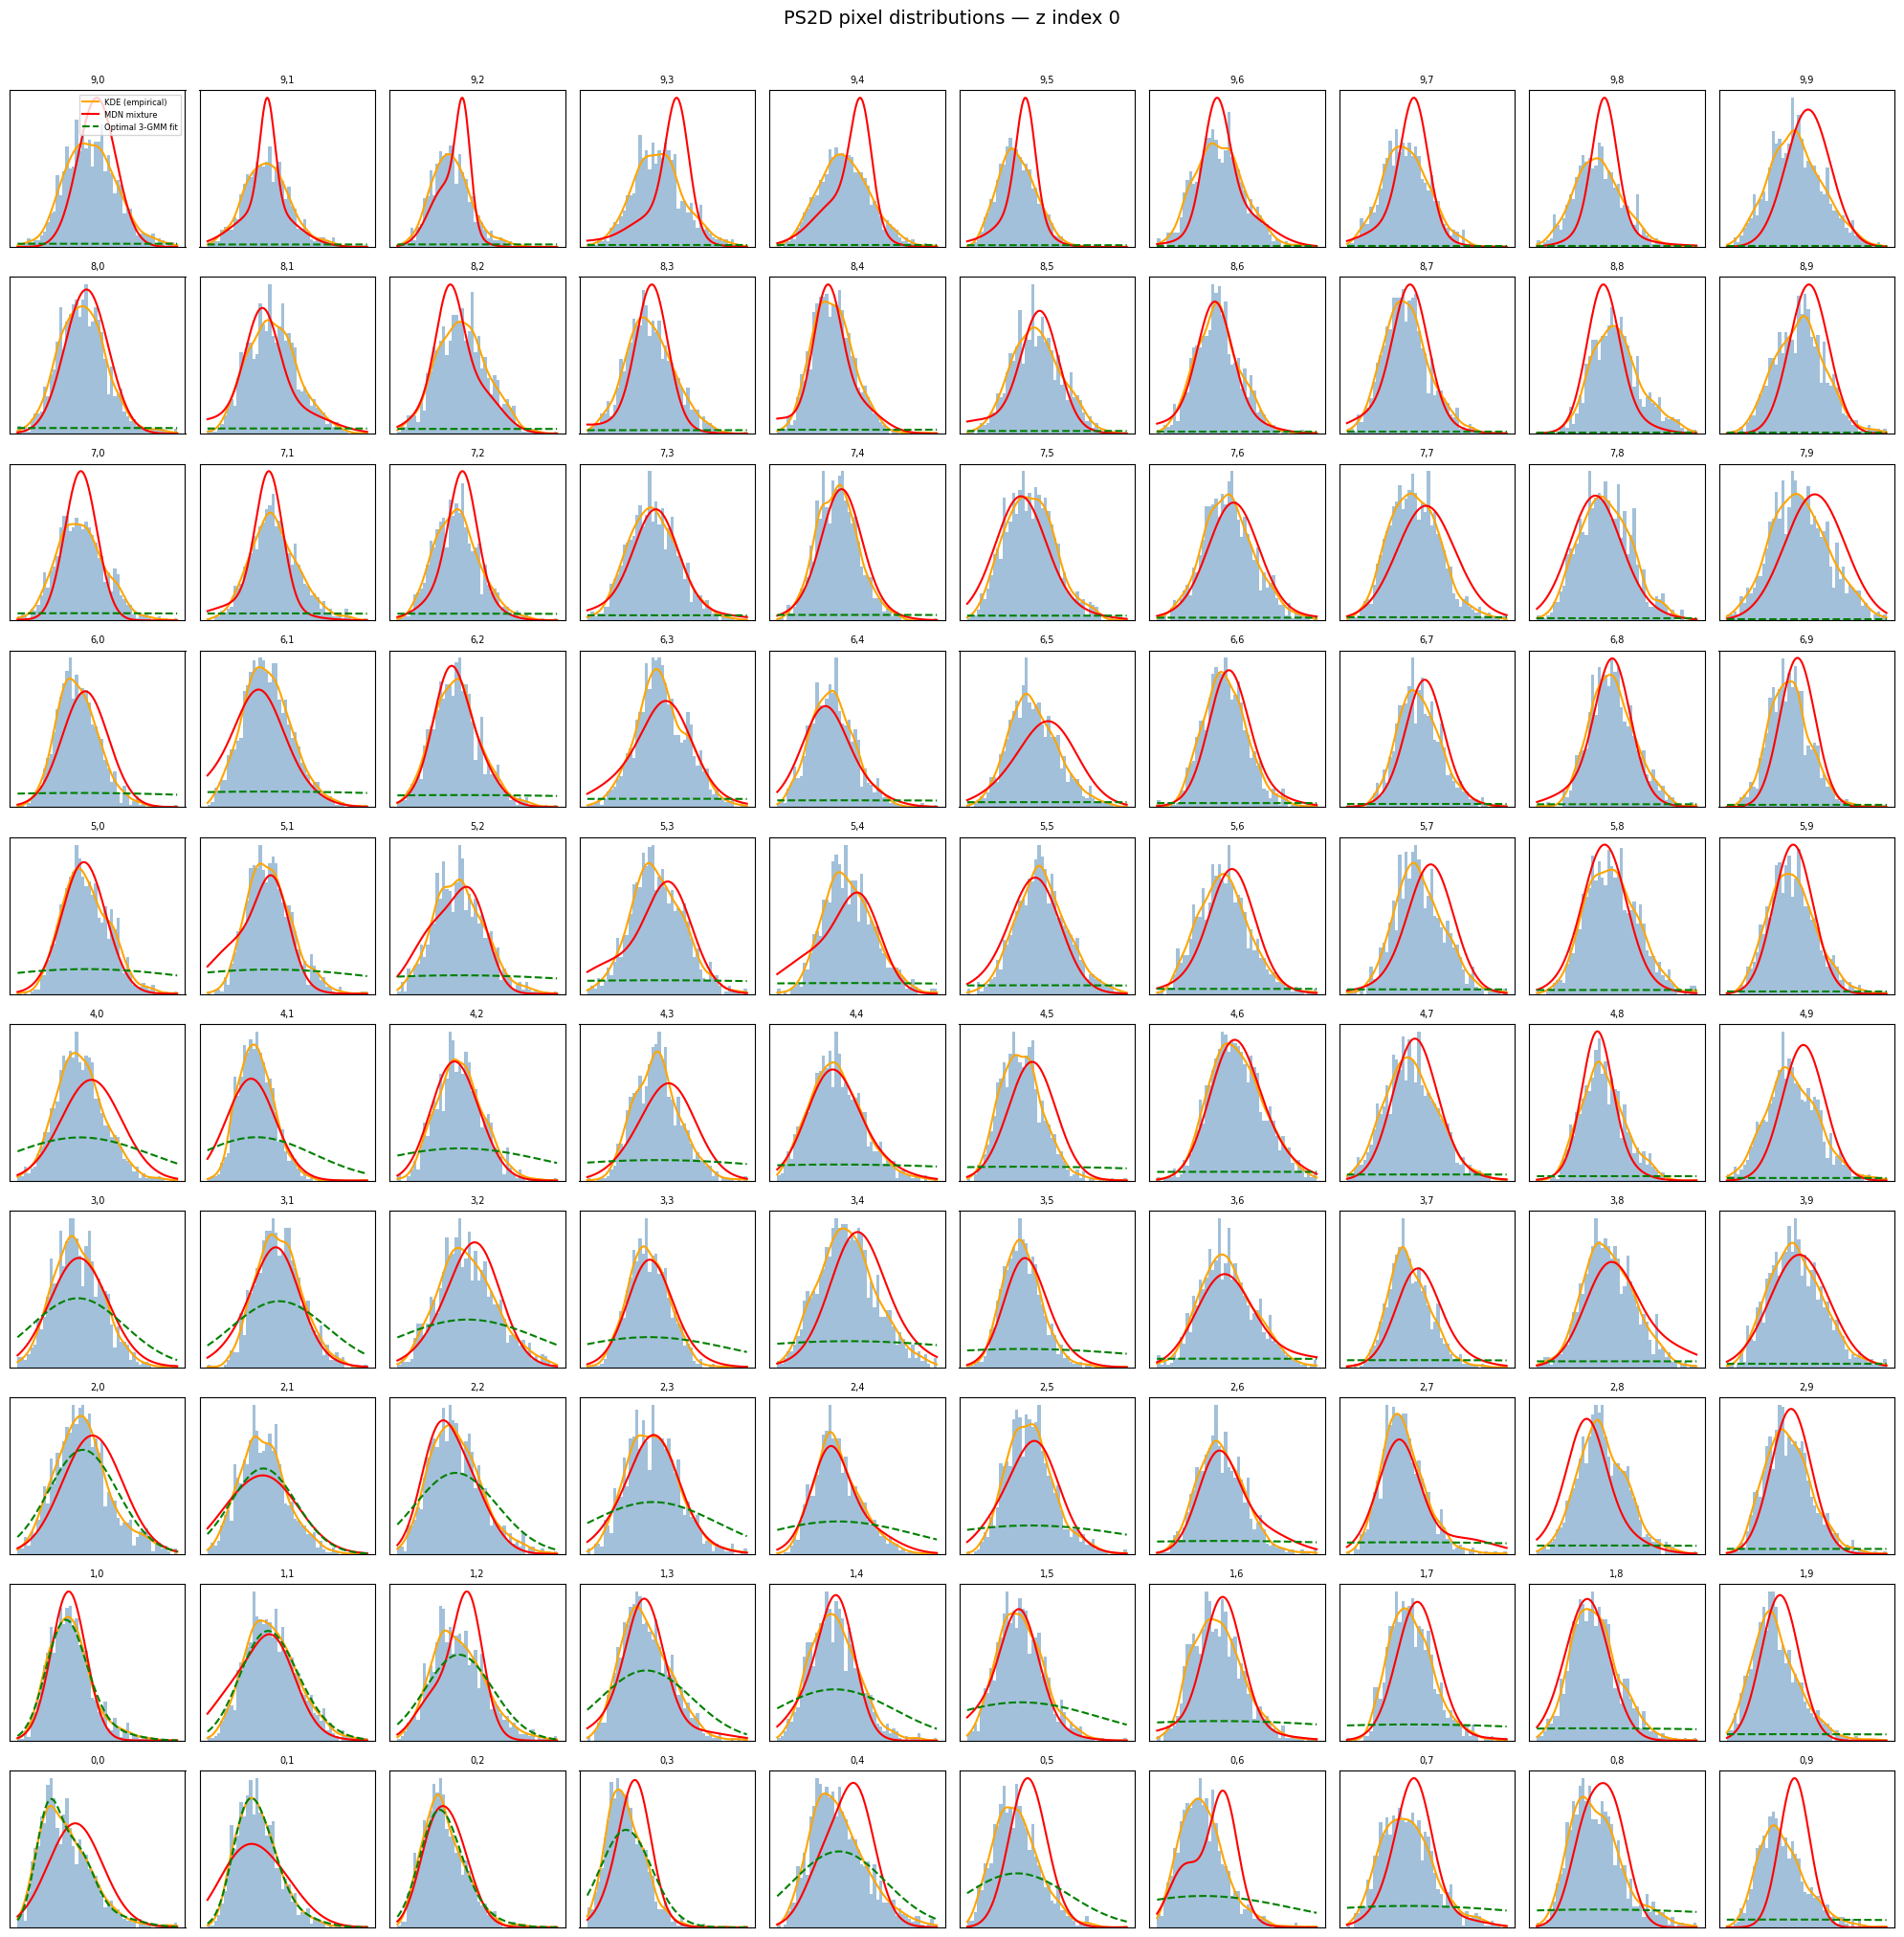

In [14]:
from scipy.stats import gaussian_kde, norm
from sklearn.mixture import GaussianMixture

z_idx = 0
K = ps2d_pi.shape[2]  # number of mixture components

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
for i in range(10):
    for j in range(10):
        ax = axes[9-i, j]

        x  = all_ps2[:, z_idx, i, j]
        xx = np.linspace(x.min(), x.max(), 300)

        ax.hist(x, bins=50, density=True, alpha=0.5, color="steelblue")
        ax.plot(xx, gaussian_kde(x)(xx), color="orange", linewidth=1.5)

        # MDN mixture PDF — directly in linear space
        mixture_pdf = np.zeros_like(xx)
        for k in range(K):
            pi_k  = ps2d_pi [0, z_idx, k, i, j]
            mu_k  = ps2d_mu [0, z_idx, k, i, j]
            sig_k = ps2d_std[0, z_idx, k, i, j]
            mixture_pdf += pi_k * norm.pdf(xx, mu_k, sig_k)

        ax.plot(xx, mixture_pdf, color="red", linewidth=1.5)

        # Optimal K-component GMM fit on the empirical data (EM algorithm)
        gmm = GaussianMixture(n_components=K, covariance_type="full", random_state=0)
        gmm.fit(x.reshape(-1, 1))

        optimal_pdf = np.zeros_like(xx)
        for k in range(K):
            w_k   = gmm.weights_[k]
            mu_k  = gmm.means_[k, 0]
            std_k = np.sqrt(gmm.covariances_[k, 0, 0])
            optimal_pdf += w_k * norm.pdf(xx, mu_k, std_k)

        ax.plot(xx, optimal_pdf, color="green", linewidth=1.5, linestyle="--")

        #ax.axvline(ps2d_mean[0, z_idx, i, j], color="red",  linestyle="--", linewidth=1.2)
        #ax.axvline(x.mean(),                  color="blue", linestyle="-",  linewidth=1.2)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{i},{j}", fontsize=7)

# Build a manual legend so it's clear which curve is which
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="orange", lw=1.5, label="KDE (empirical)"),
    Line2D([0], [0], color="red",    lw=1.5, label="MDN mixture"),
    Line2D([0], [0], color="green",  lw=1.5, linestyle="--", label=f"Optimal {K}-GMM fit"),
]
axes[0, 0].legend(handles=legend_handles, fontsize=6, loc="upper right")

plt.suptitle(f"PS2D pixel distributions — z index {z_idx}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1372565/2609340899.py:48: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(gmm_pdf, bin_centers, counts, p0=p0, maxfev=10000)


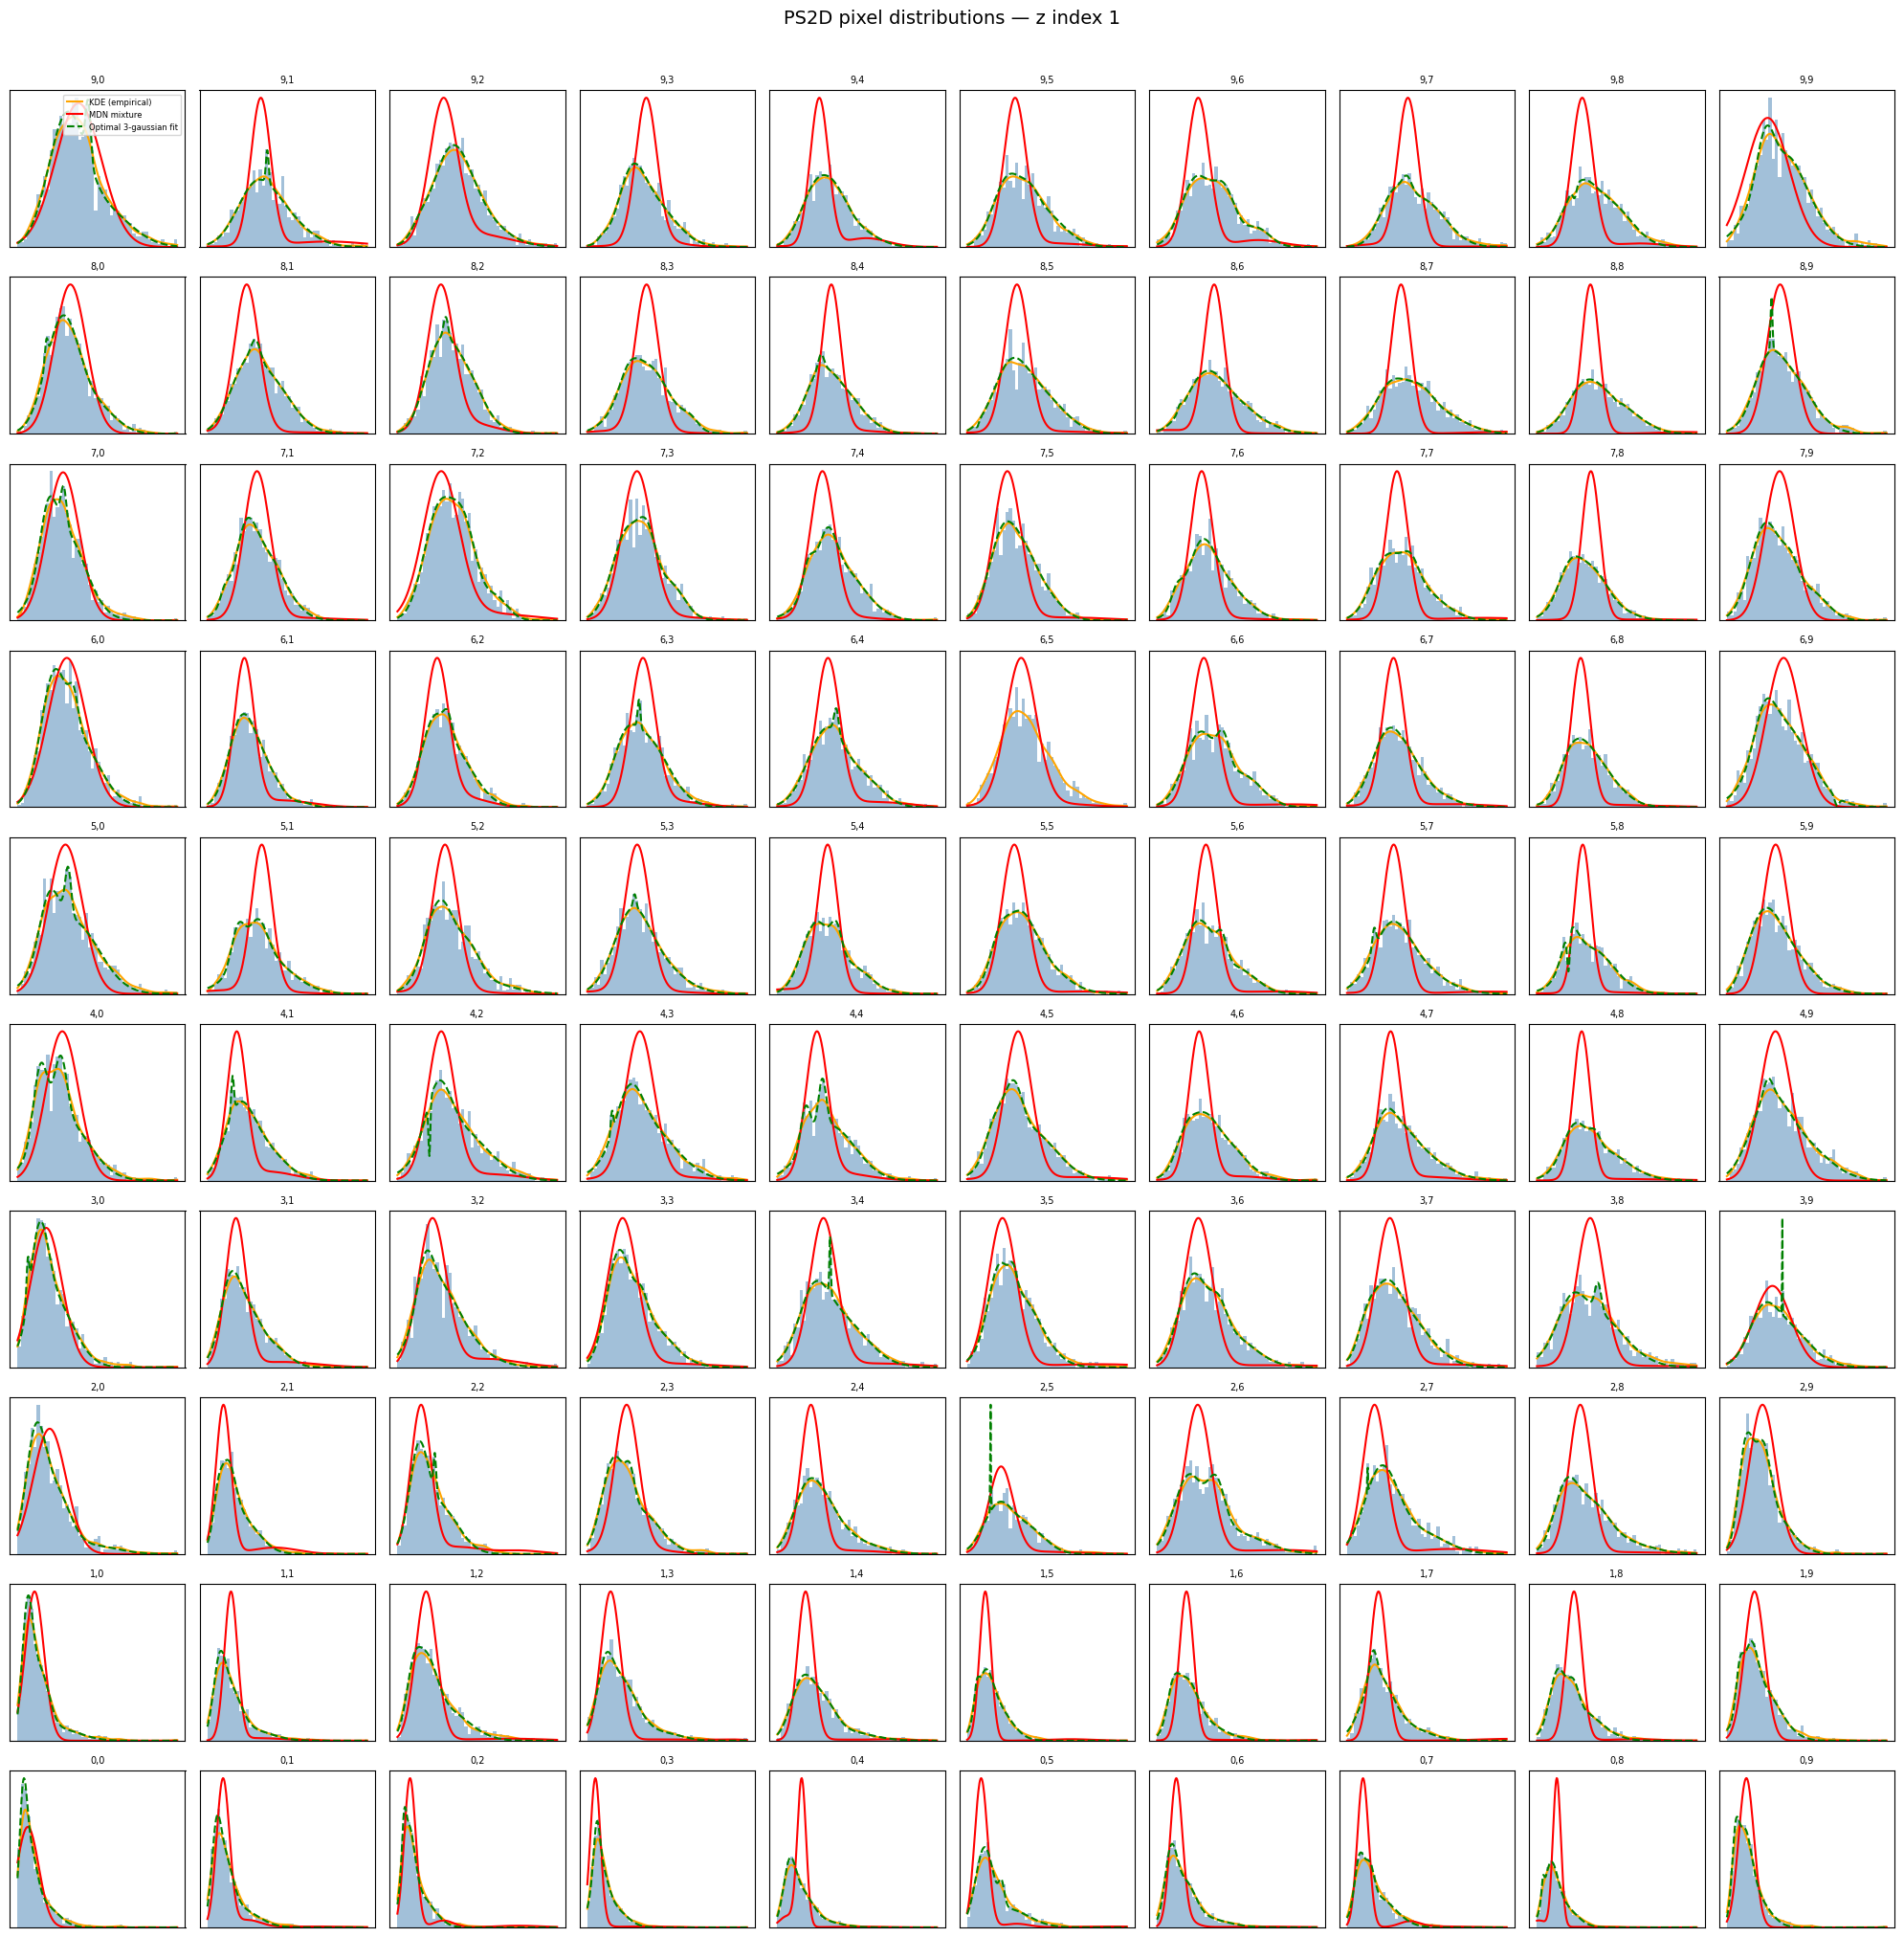

: 

In [ ]:
from scipy.stats import gaussian_kde, norm
from scipy.optimize import curve_fit

z_idx = 1
K = ps2d_pi.shape[2]

def gmm_pdf(x, *params):
    # params = [w_0, ..., w_{K-1}, mu_0, ..., mu_{K-1}, sig_0, ..., sig_{K-1}]
    w   = np.array(params[0*K:1*K])
    mu  = np.array(params[1*K:2*K])
    sig = np.abs(np.array(params[2*K:3*K]))  # keep sigma positive
    w   = w / w.sum()  # normalize weights to sum to 1
    pdf = np.zeros_like(x)
    for k in range(K):
        pdf += w[k] * norm.pdf(x, mu[k], sig[k])
    return pdf

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
for i in range(10):
    for j in range(10):
        ax = axes[9-i, j]

        x  = all_ps2[:, z_idx, i, j]
        xx = np.linspace(x.min(), x.max(), 300)

        counts, bin_edges = np.histogram(x, bins=50, density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        ax.hist(x, bins=50, density=True, alpha=0.5, color="steelblue")
        ax.plot(xx, gaussian_kde(x)(xx), color="orange", linewidth=1.5)

        # MDN mixture PDF
        mixture_pdf = np.zeros_like(xx)
        for k in range(K):
            pi_k  = ps2d_pi [0, z_idx, k, i, j]
            mu_k  = ps2d_mu [0, z_idx, k, i, j]
            sig_k = ps2d_std[0, z_idx, k, i, j]
            mixture_pdf += pi_k * norm.pdf(xx, mu_k, sig_k)
        ax.plot(xx, mixture_pdf, color="red", linewidth=1.5)

        # Optimal K-gaussian fit — direct least-squares on the histogram
        init_w   = np.ones(K) / K
        init_mu  = np.quantile(x, np.linspace(0.1, 0.9, K))
        init_sig = np.full(K, x.std() / K)
        p0 = np.concatenate([init_w, init_mu, init_sig])

        try:
            popt, _ = curve_fit(gmm_pdf, bin_centers, counts, p0=p0, maxfev=10000)
            optimal_pdf = gmm_pdf(xx, *popt)
            ax.plot(xx, optimal_pdf, color="green", linewidth=1.5, linestyle="--")
        except RuntimeError:
            pass  # fit failed to converge for this pixel, skip the green curve

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{i},{j}", fontsize=7)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="orange", lw=1.5, label="KDE (empirical)"),
    Line2D([0], [0], color="red",    lw=1.5, label="MDN mixture"),
    Line2D([0], [0], color="green",  lw=1.5, linestyle="--", label=f"Optimal {K}-gaussian fit"),
]
axes[0, 0].legend(handles=legend_handles, fontsize=6, loc="upper right")

plt.suptitle(f"PS2D pixel distributions — z index {z_idx}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
xhi_cur.numpy()

NameError: name 'xhi_cur' is not defined

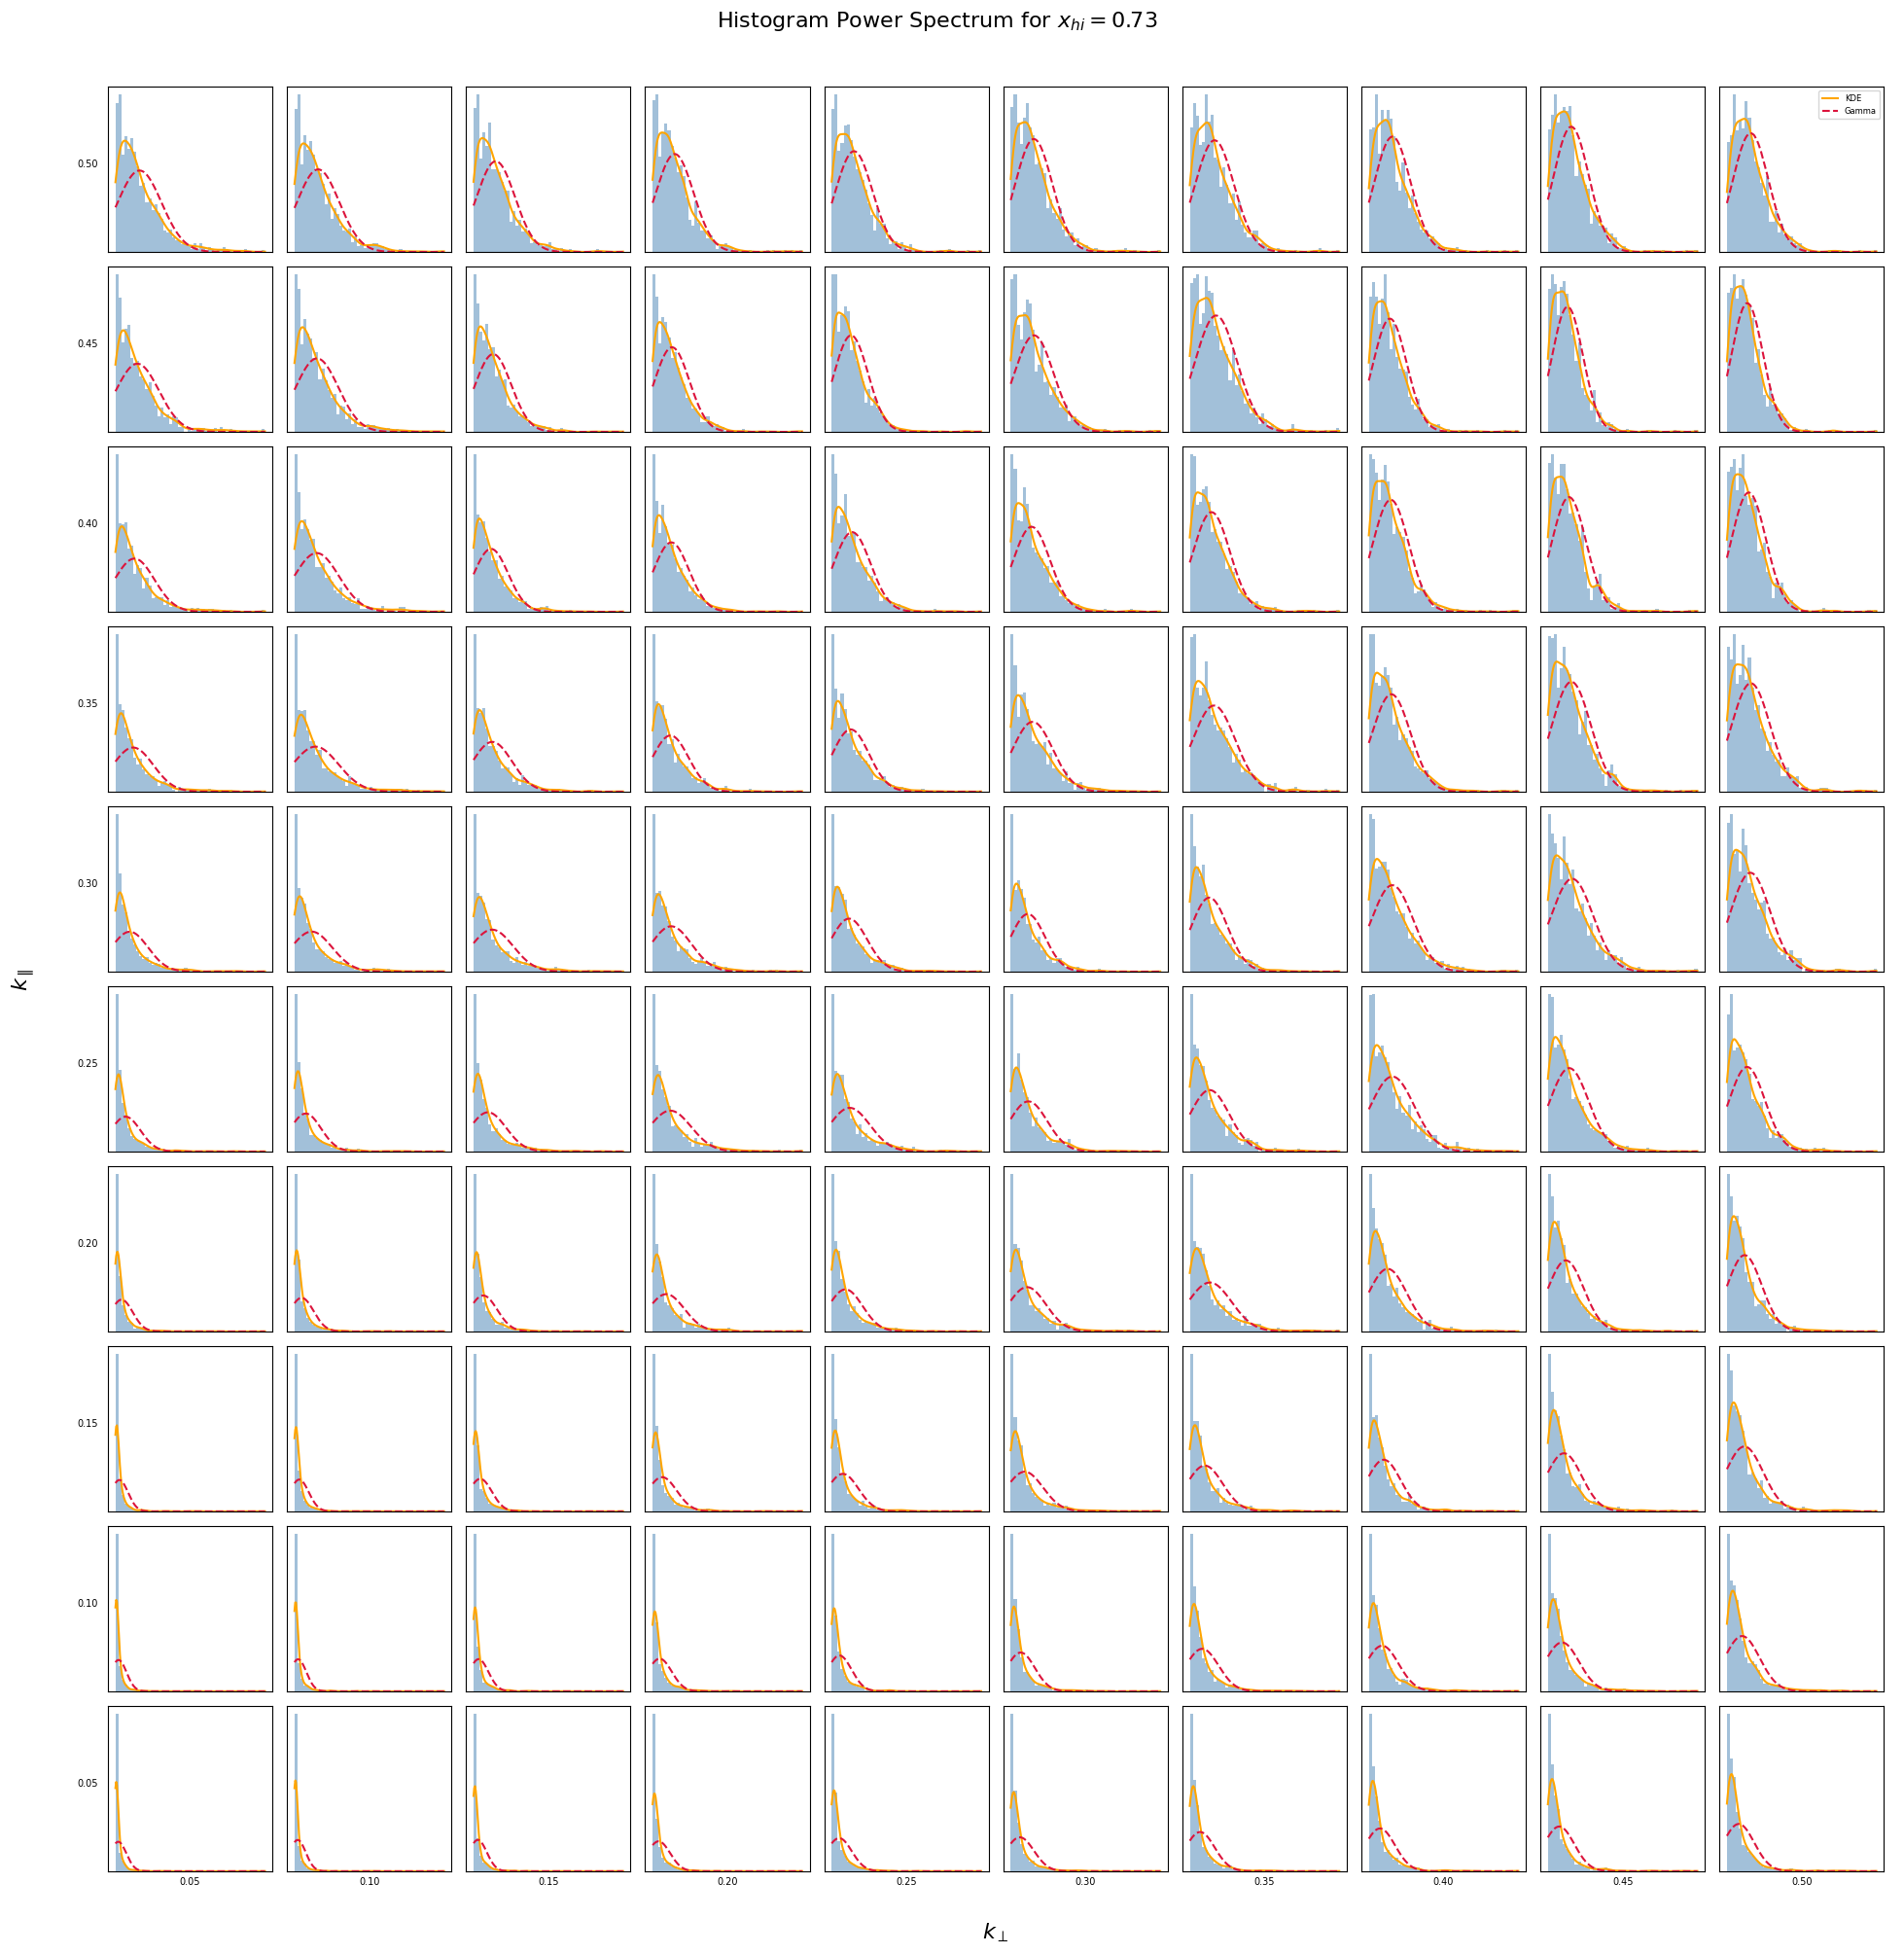

In [ ]:
from scipy.stats import lognorm, norm, gamma
from scipy.stats import gaussian_kde

z = 2
kpar  = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kperp = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
xhi = xhi_cur[0][z].numpy().round(2)
fig.suptitle(r'Histogram Power Spectrum for $x_{hi} = $' + str(xhi), fontsize=16, y=1.01)

big_ax = fig.add_subplot(111, frameon=False)
big_ax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
big_ax.set_xlabel(r'$k_\perp$', fontsize=16, labelpad=20)
big_ax.set_ylabel(r'$k_\parallel$', fontsize=16, labelpad=30)

for i in range(10):
    for j in range(10):
        ax  = axes[9-i, j]
        x   = all_ps2[:, z, i, j]
        #x = x**(1/3)  # Transform to reduce skewness
        xx  = np.linspace(x.min(), x.max(), 200)


        ax.hist(x, bins=50, density=True, alpha=0.5, color='steelblue')

        # KDE
        kde = gaussian_kde(x)
        ax.plot(xx, kde(xx), color='orange', linewidth=1.5, label='KDE')

        # Gamma fit
        a, loc, scale = gamma.fit(x, floc=0)   
        ax.plot(xx, gamma.pdf(xx, a, loc=loc, scale=scale),
                color='crimson', linewidth=1.5, linestyle='--', label='Gamma')

        ax.set_xticks([])
        ax.set_yticks([])
        mean = np.mean(x)
        var  = np.var(x)

        R_theory   = mean**2 / var
        eta_theory = var / mean

# Add legend once on the last subplot
axes[0, 9].legend(fontsize=6, loc='upper right')

for j in range(10):
    axes[9, j].set_xlabel(f'{kperp[j]:.2f}', fontsize=7)
for i in range(10):
    axes[9-i, 0].set_ylabel(f'{kpar[i]:.2f}', fontsize=7, rotation=0, labelpad=15)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
os.makedirs("figures/gamma", exist_ok=True)
plt.savefig(f"figures/gamma/ps_xh_{xhi.round(2)}.png", dpi=150, bbox_inches='tight')
plt.show()

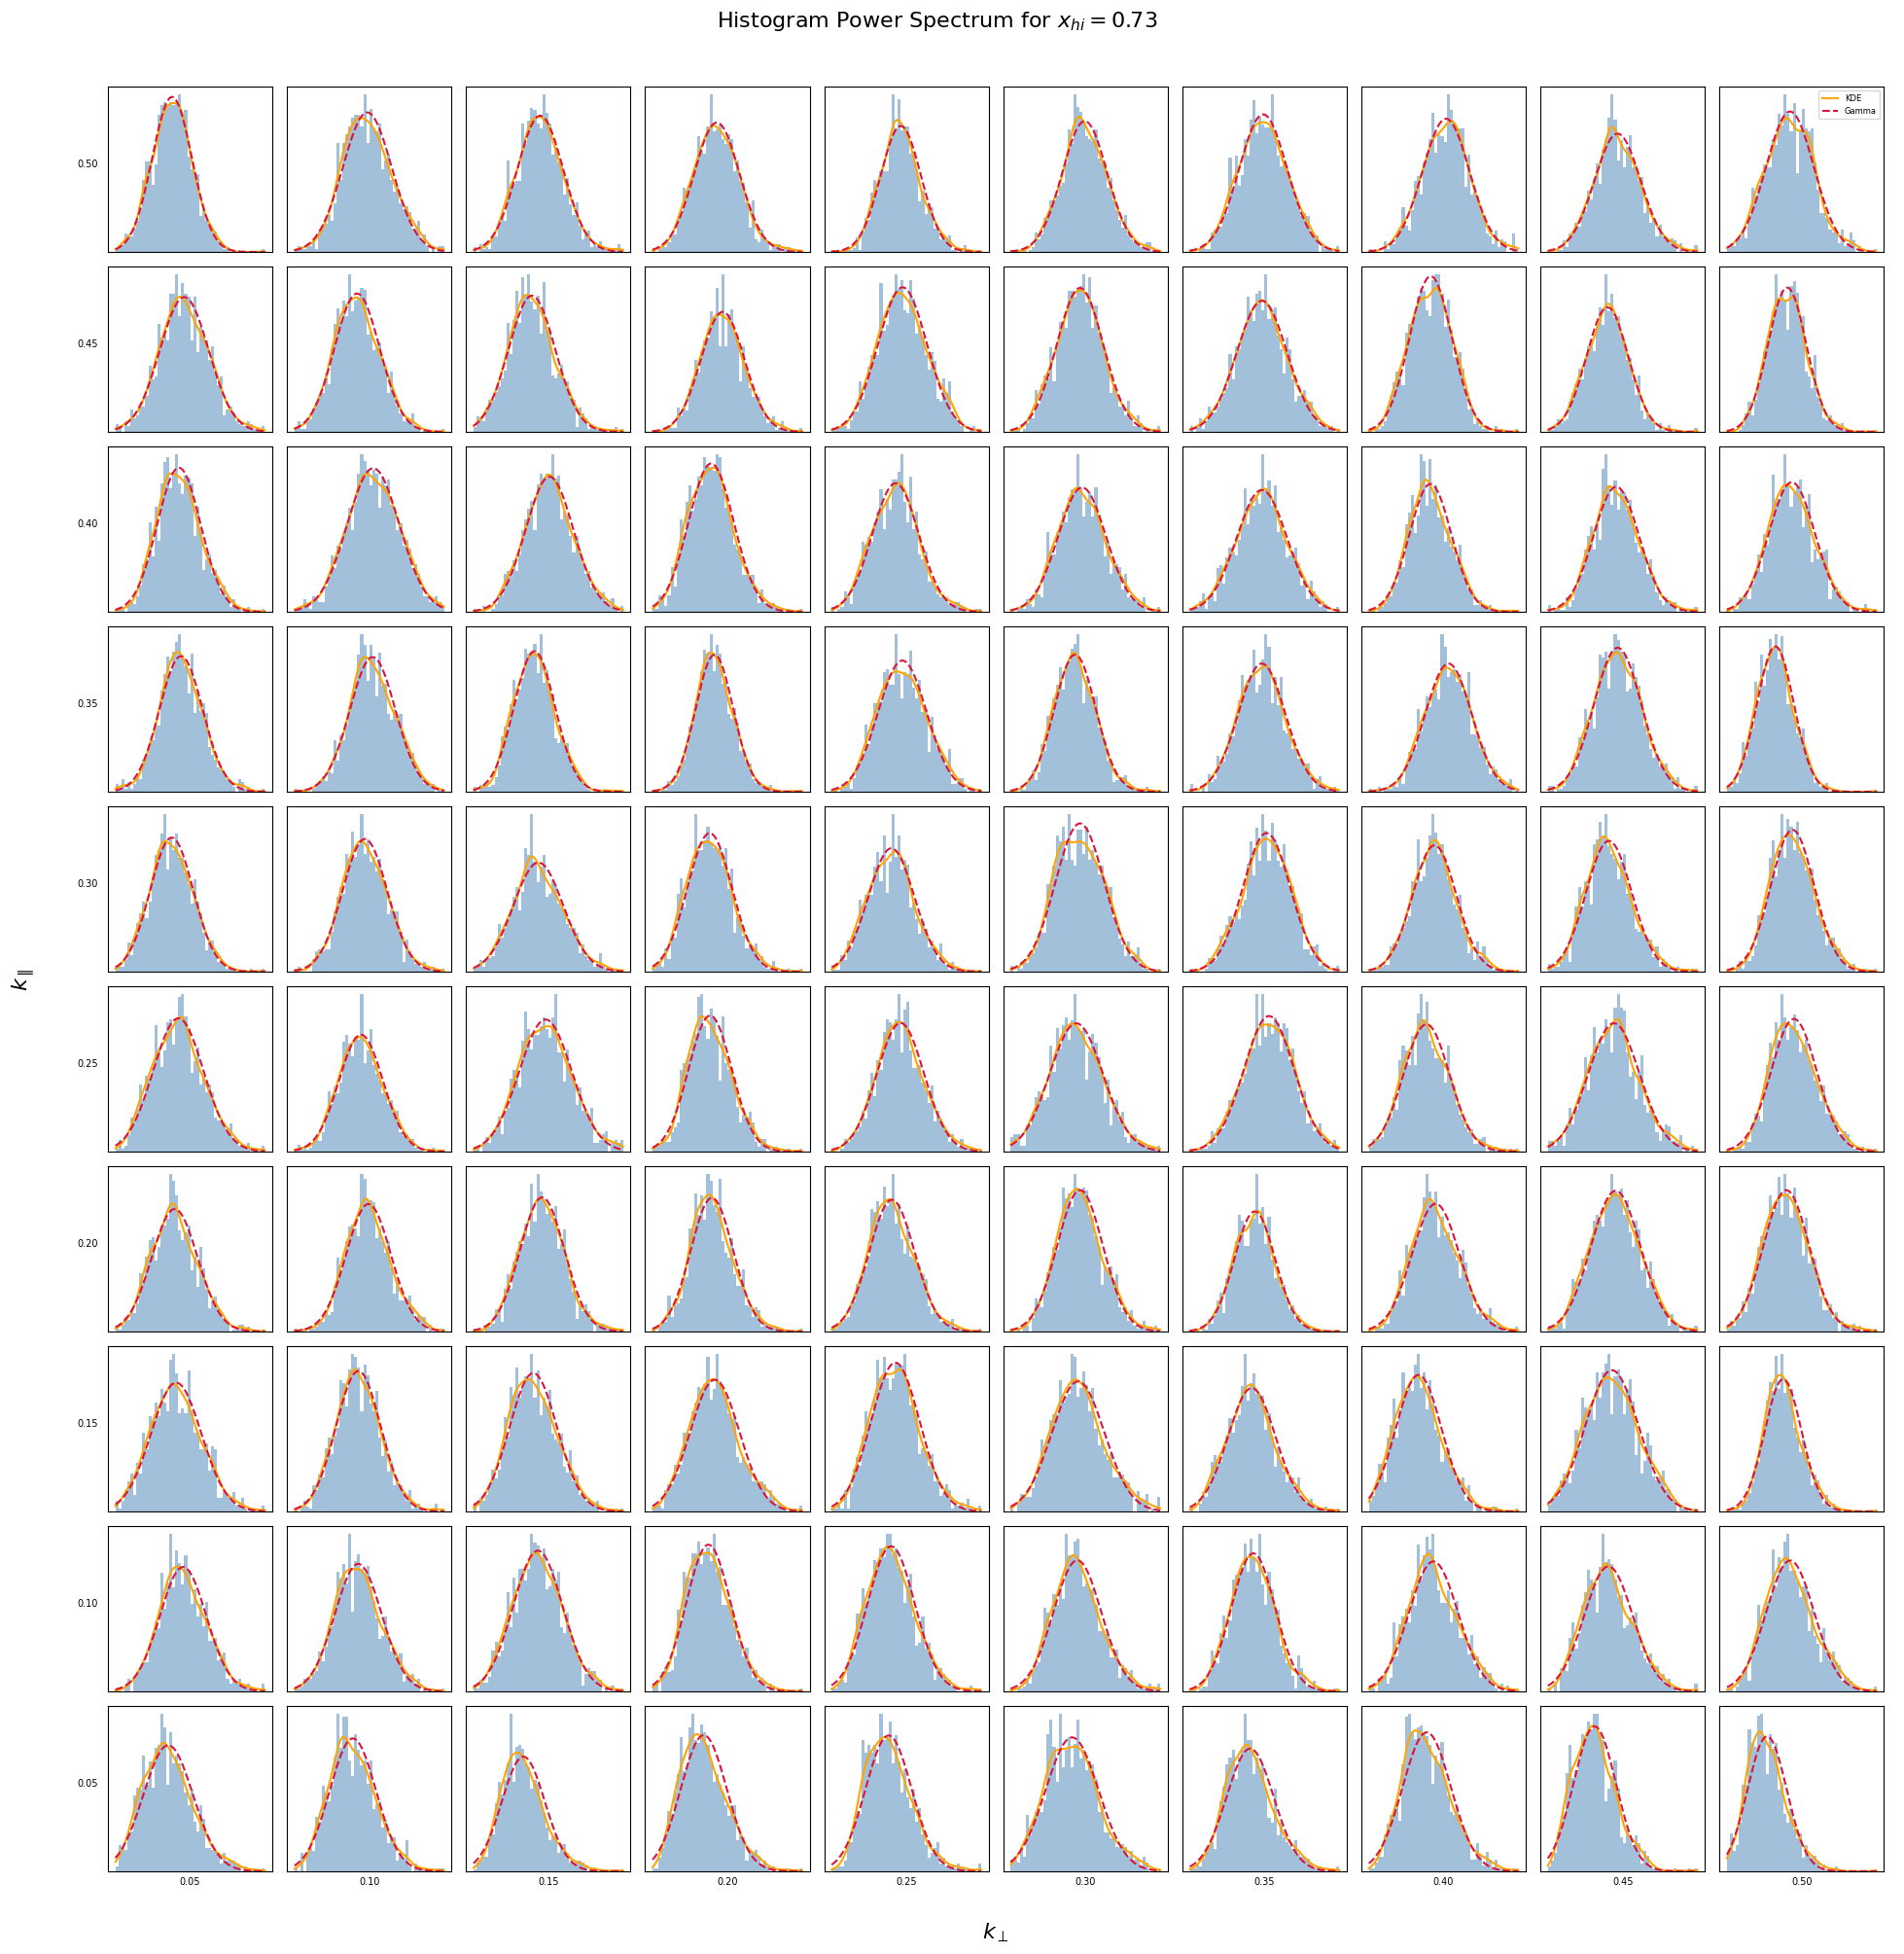

In [ ]:
from scipy.stats import lognorm, norm, gamma
from scipy.stats import gaussian_kde

z = 2
kpar  = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kperp = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
xhi = xhi_cur[0][z].numpy().round(2)
fig.suptitle(r'Histogram Power Spectrum for $x_{hi} = $' + str(xhi), fontsize=16, y=1.01)

big_ax = fig.add_subplot(111, frameon=False)
big_ax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
big_ax.set_xlabel(r'$k_\perp$', fontsize=16, labelpad=20)
big_ax.set_ylabel(r'$k_\parallel$', fontsize=16, labelpad=30)

for i in range(10):
    for j in range(10):
        ax  = axes[9-i, j]
        x   = all_ps3[:, z, i, j]
        xx  = np.linspace(x.min(), x.max(), 200)


        ax.hist(x, bins=50, density=True, alpha=0.5, color='steelblue')

        # KDE
        kde = gaussian_kde(x)
        ax.plot(xx, kde(xx), color='orange', linewidth=1.5, label='KDE')

        # Gamma fit
        ax.plot(xx, norm.pdf(xx, loc=np.mean(x), scale=np.std(x)),
                color='crimson', linewidth=1.5, linestyle='--', label='Gamma')

        ax.set_xticks([])
        ax.set_yticks([])

# Add legend once on the last subplot
axes[0, 9].legend(fontsize=6, loc='upper right')

for j in range(10):
    axes[9, j].set_xlabel(f'{kperp[j]:.2f}', fontsize=7)
for i in range(10):
    axes[9-i, 0].set_ylabel(f'{kpar[i]:.2f}', fontsize=7, rotation=0, labelpad=15)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
os.makedirs("figures/gamma", exist_ok=True)
plt.savefig(f"figures/gamma/ps_xh_{xhi.round(2)}.png", dpi=150, bbox_inches='tight')
plt.show()

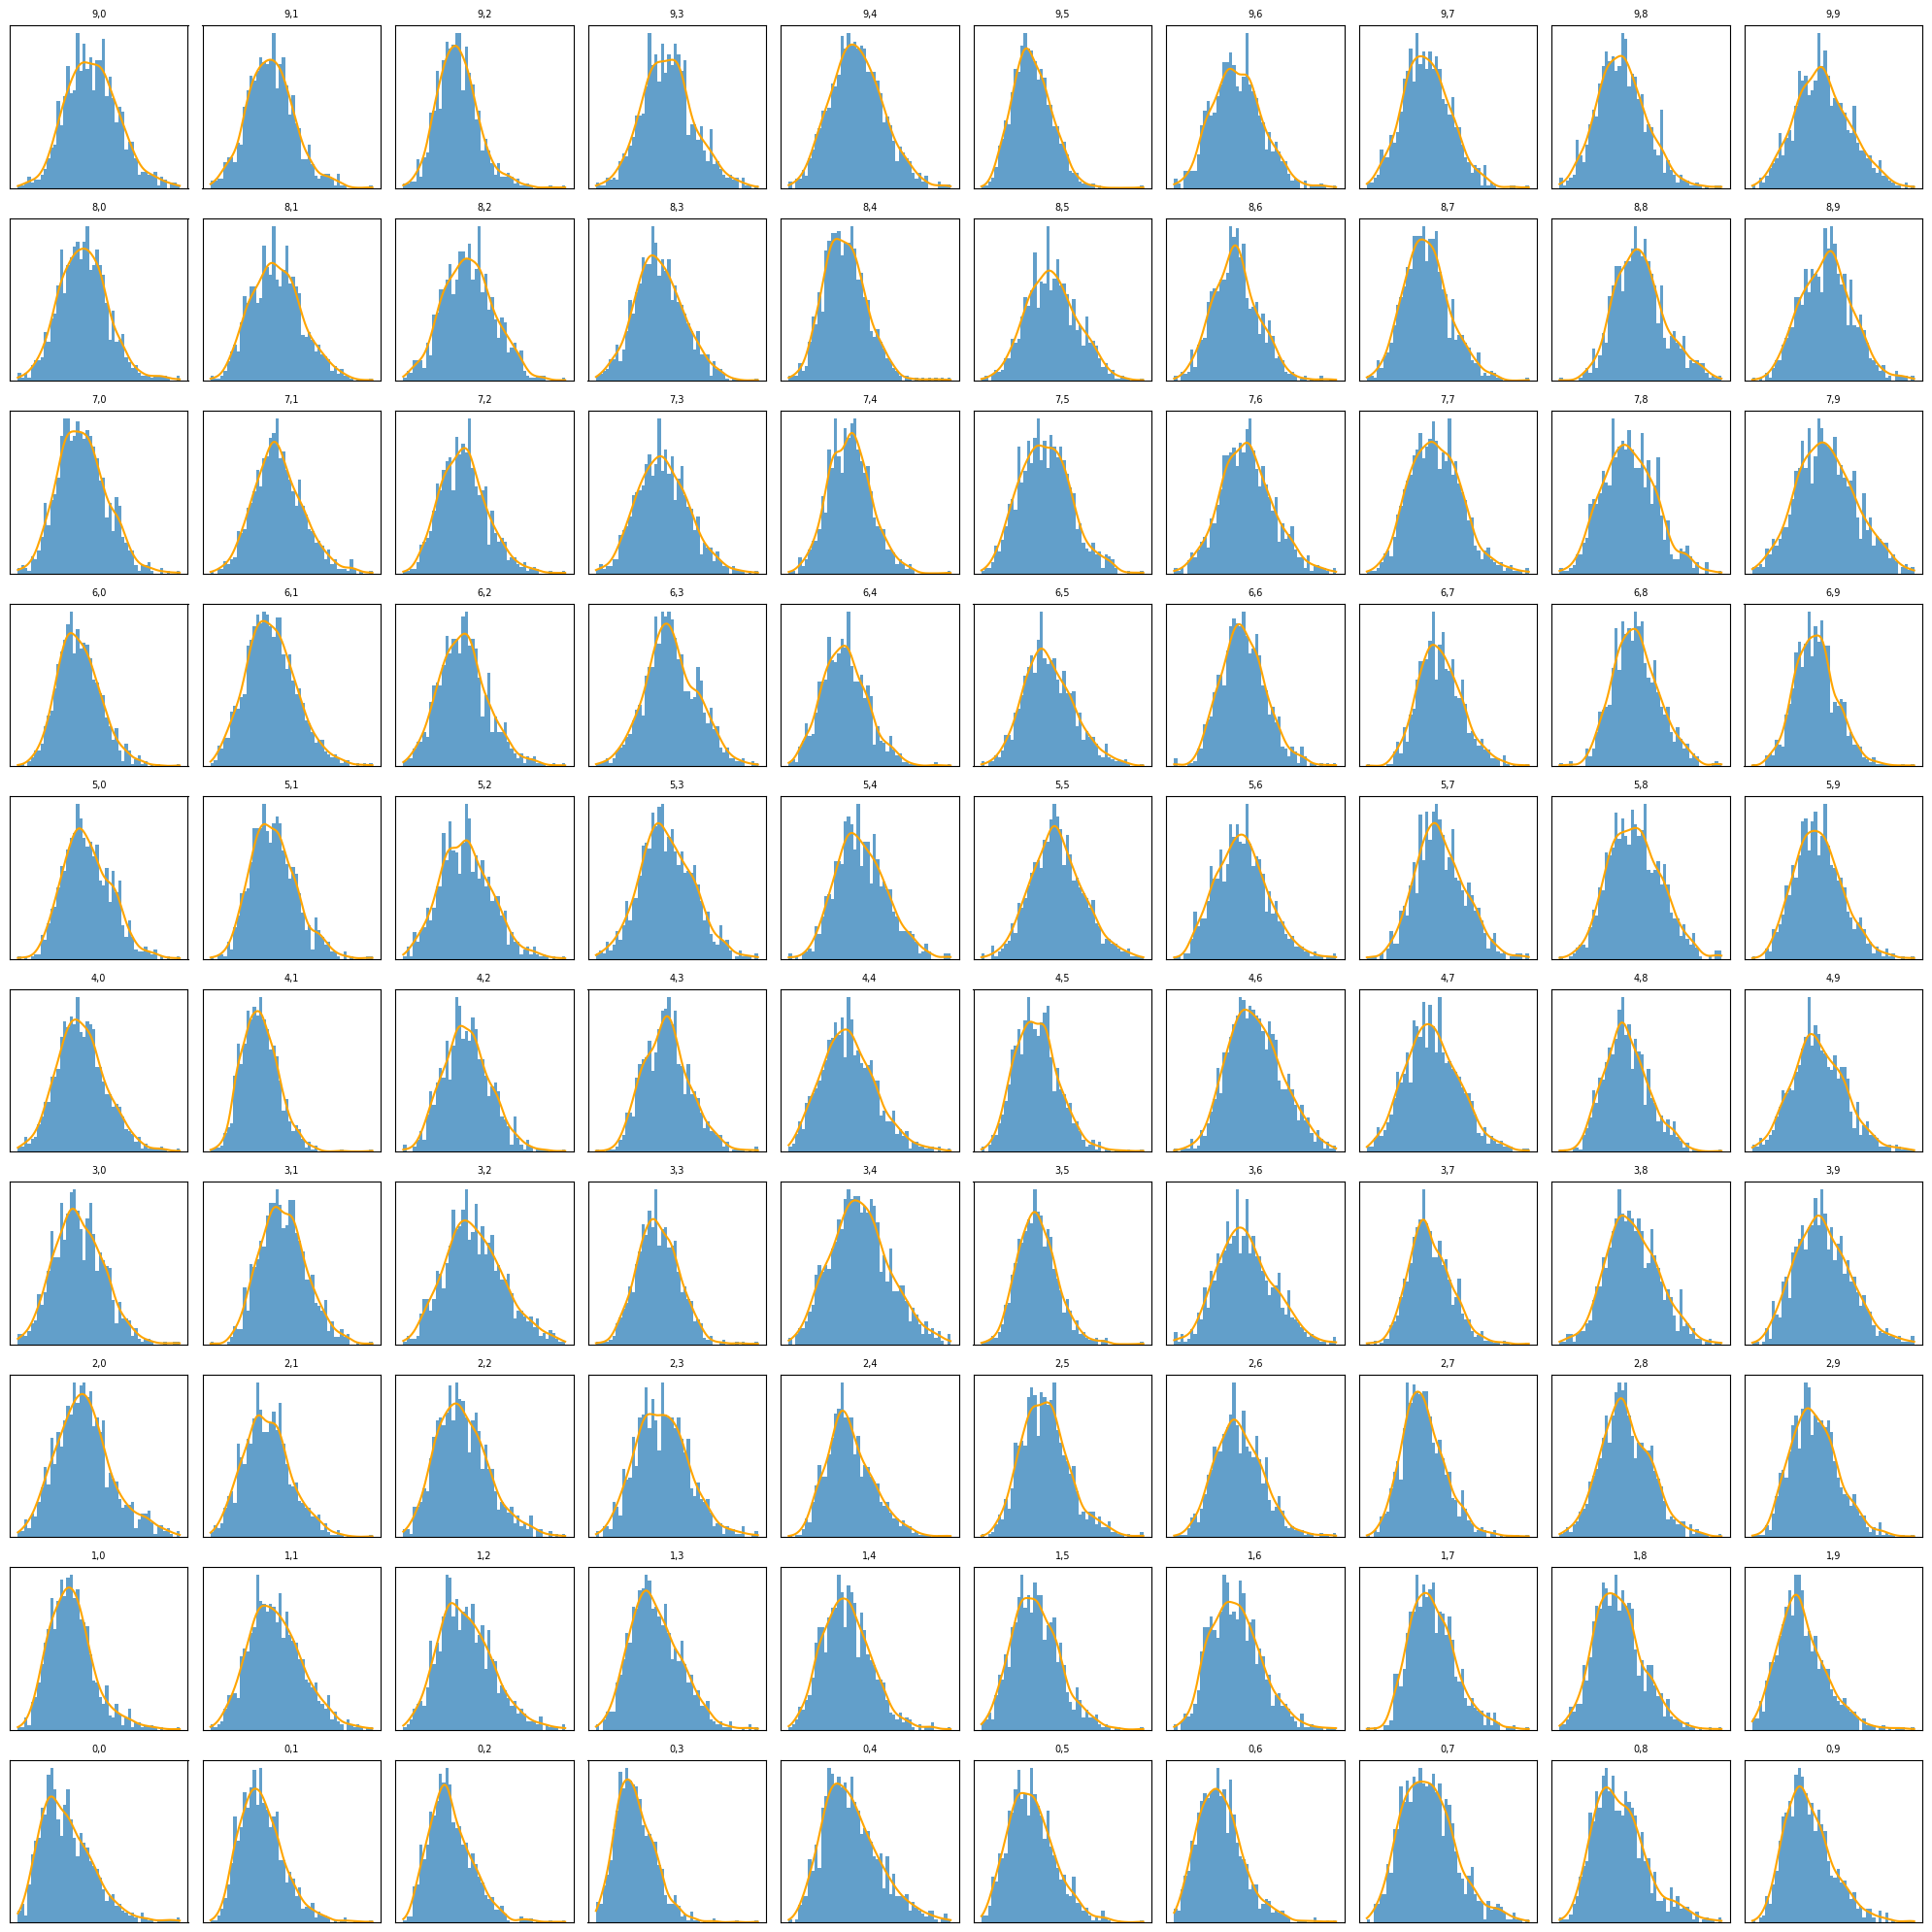

In [ ]:
from scipy.stats import lognorm, norm
from scipy.stats import gaussian_kde

z = 0
fig, axes = plt.subplots(10, 10, figsize=(20, 20))

EPS = 1e-8

for i in range(10):
    for j in range(10):
        ax = axes[9-i, j]         
        x = all_ps2[:, z, i, j]
        predicted_val_log = ps_mu_log10[0, z, i, j] 
        predicted_sigma_log = ps_sigma_log10[0,z, i, j]
        predicted_val = ps2d_cur[0, z, i, j]
        predicted_sigma = ps2d_sigma_cur[0, z, i, j]
        mu = np.mean(x)
        sigma = np.std(x)
        mu_log = np.mean(np.log(x))
        sigma_log = np.std(np.log(x))
        ax.hist(x, bins=50, density=True, alpha=0.7)

        xx = np.linspace(x.min(), x.max(), 200)
        kde = gaussian_kde(x)
        ax.plot(xx, kde(xx), color='orange', linewidth=1.5, label='KDE')
        ax.plot(xx, norm.pdf(xx, predicted_val, predicted_sigma))
        ax.axvline(mu, color='blue', linestyle='-', linewidth=2, label='Empirical Mean')
        # 6. Cosmétique
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{i},{j}", 
                     fontsize=7)

plt.tight_layout()
plt.show()